# 10 Multiscale edges: worms

Upward continue the field to a ladder of heights, take the total
horizontal derivative at each, keep the pixels where it is a local
maximum along the gradient direction, threshold, and link the survivors
into strings. Each height gives an edge map; stacked over height the
strings become three-dimensional objects that behave according to the
source geometry (Hornby, Boschetti and Horowitz 1999; Archibald, Gow and
Boschetti 1999; Holden et al. 2000):

- a vertical contact gives a string that stays put with height;
- a dipping contact gives a string that migrates down-dip. The string
  bisects the angle between the contact and the vertical, so the true dip
  is 2 x (string dip) - 90 degrees. `worms.contact_dip` applies this; it
  is checked against the 2D forward model at 30, 45 and 60 degrees;
- a thin dyke gives a pair of flank strings that diverge with height;
- a small shallow body dies out at low heights, a crustal structure
  persists to tens of kilometres;
- the amplitude of a string decays with height at a rate set by the
  source: as 1/(h + z0) over a contact in RTP magnetics, so the decay
  gives the depth to the top (`worms.depth_from_decay`).

The implementation here shares one FFT across all heights and both
derivatives. Frank Horowitz's bsdwormer is an earlier open version of the
same idea; the commercial one lived in Encom and Geosoft.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from potfield import read_grid, write_grid, filters, transforms, spectrum, display

DATA = "../data"
OUT = "../outputs"
INC, DEC = -62.4, 7.5   # IGRF inclination, declination (deg) for the Frome area at 2015.0
plt.rcParams["figure.dpi"] = 90

In [2]:
from potfield import Grid, worms, model2d
from rasterio.crs import CRS
from rasterio.transform import from_origin

## Synthetic: three structures on one grid

A 2D section with a vertical thin dyke at x = -20 km, and a block whose
western contact at x = -8 km dips 45 degrees east and whose eastern
contact at x = 22 km is vertical, both with their tops at 400 m. The block
is 30 km wide and 60 km deep so its two contacts behave as isolated
contacts up to the highest level used here, 3 km. The section is tiled
north-south into a grid, so the structures strike north, and the RTP
field is computed at the pole.

5926 edge points at 8 heights


<Axes: title={'center': 'synthetic worms, 8 levels'}, xlabel='Easting (km)', ylabel='Northing (km)'>

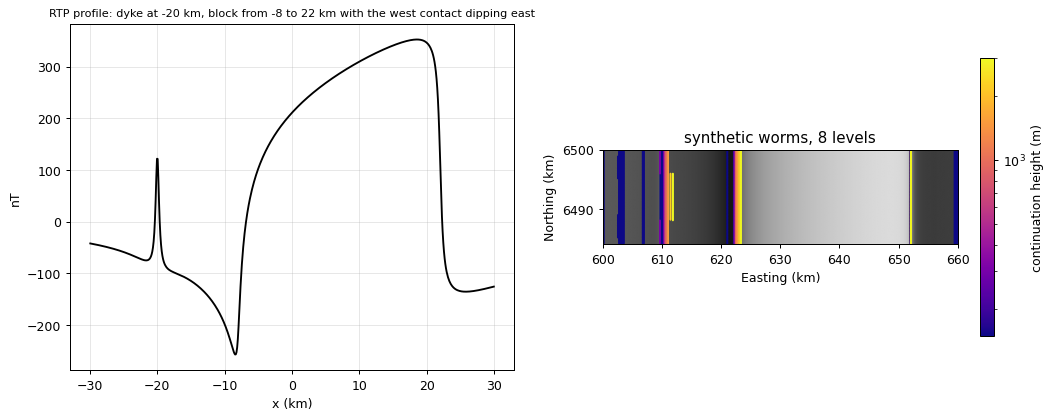

In [3]:
DXS, NXS, NYS = 100.0, 600, 160                      # 60 km by 16 km
g0 = Grid(np.zeros((NYS, NXS)), from_origin(600e3, 6500e3, DXS, DXS), CRS.from_epsg(28354), name="synthetic", units="nT")
xrel = g0.x - g0.x.mean()
top, bottom = 400.0, 60e3
shift = (bottom - top) / np.tan(np.radians(45.0))
bodies = [
    model2d.dyke(-20e3, 300.0, 150.0, 90.0, 3000.0, susceptibility=0.05, name="dyke"),
    model2d.Body([-8e3, 22e3, 22e3, -8e3 + shift], [top, top, bottom, bottom], susceptibility=0.02, name="block"),
]
profile = model2d.magnetic(bodies, xrel, 90.0, 0.0, 90.0, 56671.0)
syn = g0.with_values(np.tile(profile, (NYS, 1)))
heights = np.array([0.0, 150.0, 300.0, 600.0, 1000.0, 1500.0, 2200.0, 3000.0])
w = worms.multiscale_edges(syn, heights, percentile=50, min_length=20)
print(len(w), "edge points at", len(heights), "heights")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(xrel / 1e3, profile, "k"); axes[0].set_xlabel("x (km)"); axes[0].set_ylabel("nT"); axes[0].grid(alpha=0.3)
axes[0].set_title("RTP profile: dyke at -20 km, block from -8 to 22 km with the west contact dipping east", fontsize=9)
worms.plot_map(w, ax=axes[1], grid=syn, s=2)

Text(0.5, 0.92, 'vertical contact stays, dipping contact migrates east, dyke flanks diverge')

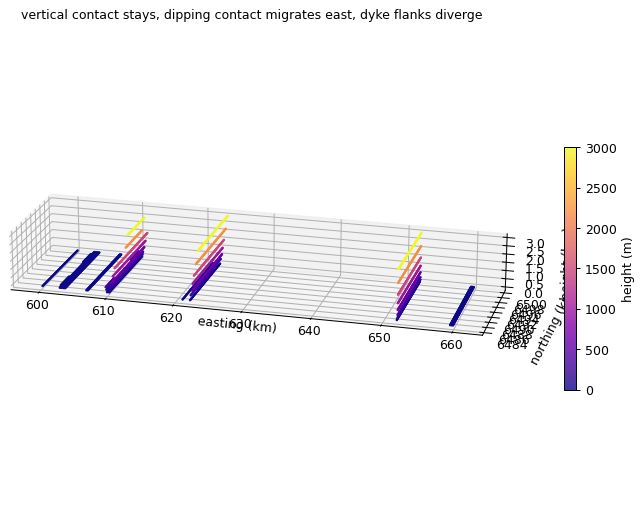

In [4]:
ax = worms.plot_3d(w, vertical="up", exaggeration=2.5, s=3, elev=20, azim=-75)
ax.set_title("vertical contact stays, dipping contact migrates east, dyke flanks diverge", fontsize=10)

## Read dip and depth off the strings

Link the strings across heights, take the chain over the dipping contact,
and read the dip from its migration and the depth to top from its
amplitude decay. Both numbers are known here: 45 degrees and 400 m.

In [5]:
worms.link_levels(w)
chains = worms.chains(w, min_levels=6)
print(len(chains), "chains through at least 6 heights")
for c in chains:
    p = worms.chain_profile(w, c)
    d = worms.contact_dip(w, c)
    z = worms.depth_from_decay(p["height"], p["amplitude"], n=1.0)
    x0 = (p["x"][0] - g0.x.mean()) / 1e3
    print(f"chain starting at x = {x0:6.1f} km: migration {d['shift']:6.0f} m over {p['height'][-1]:.0f} m, "
          f"contact dip {d['dip']:4.0f} toward {d['azimuth']:3.0f}, depth from decay {z['depth']:5.0f} m")

3 chains through at least 6 heights
chain starting at x =  -19.9 km: migration   1700 m over 3000 m, contact dip   31 toward  90, depth from decay  -157 m
chain starting at x =   -7.8 km: migration   1200 m over 3000 m, contact dip   46 toward  90, depth from decay   433 m
chain starting at x =   21.9 km: migration    100 m over 3000 m, contact dip   86 toward  90, depth from decay   323 m


The dipping contact chain returns the dip within a degree or two and the
depth within 10%. The vertical contact returns a near-vertical dip and a
depth about 20% shallow; the error grows with height because at 3 km the
block is no longer infinitely wide compared with the height, and the
decay steepens. The dyke chain reports a dip and a depth that mean
nothing, because the 1/(h + z0) law is for a contact; a thin dyke decays
as 1/(h + z0)^2, and its flank strings are not contacts at all. Reading
geometry off worms needs a model of what the source is, which is what the
3D picture is for.

## Eyre Peninsula

The eastern Gawler Craton has the structure this method is for: the
north-south Kalinjala Shear Zone along the eastern side of the peninsula,
the fabric of the Cleve and Spencer domains either side of it, and the
iron formations of the Middleback Ranges near Whyalla. The grid is 200 m,
already in MGA zone 53, with the sea as null. Eleven heights from 200 m
to 20 km on the RTP field, keeping the strongest 20% of ridge pixels at
each height and strings of at least 15 pixels. Null cells carry no edges,
but within a few cells of the coast the nearest-value fill used before the
FFT can make strings that are not real.

In [6]:
INC_E, DEC_E = -65.9, 6.7                                    # IGRF at 2015.0 for the peninsula
tmi = read_grid(f"{DATA}/eyre_tmi.ers", units="nT")
rtp = transforms.reduce_to_pole(tmi, INC_E, DEC_E)
heights = np.array([200, 320, 500, 800, 1250, 2000, 3200, 5000, 8000, 12500, 20000.0])
wf = worms.multiscale_edges(rtp, heights, percentile=80, min_length=15)
for i, h in enumerate(heights):
    print(f"h = {h:6.0f} m: {wf.at_level(i).sum():6d} points, {len(np.unique(wf.worm_id[wf.at_level(i)])):4d} strings")

h =    200 m:  45489 points, 1166 strings
h =    320 m:  38987 points, 1020 strings
h =    500 m:  31965 points,  828 strings
h =    800 m:  24067 points,  563 strings
h =   1250 m:  17307 points,  355 strings
h =   2000 m:  11760 points,  225 strings
h =   3200 m:   7848 points,  146 strings
h =   5000 m:   5349 points,  100 strings
h =   8000 m:   3721 points,   53 strings
h =  12500 m:   2754 points,   29 strings
h =  20000 m:   1872 points,   17 strings


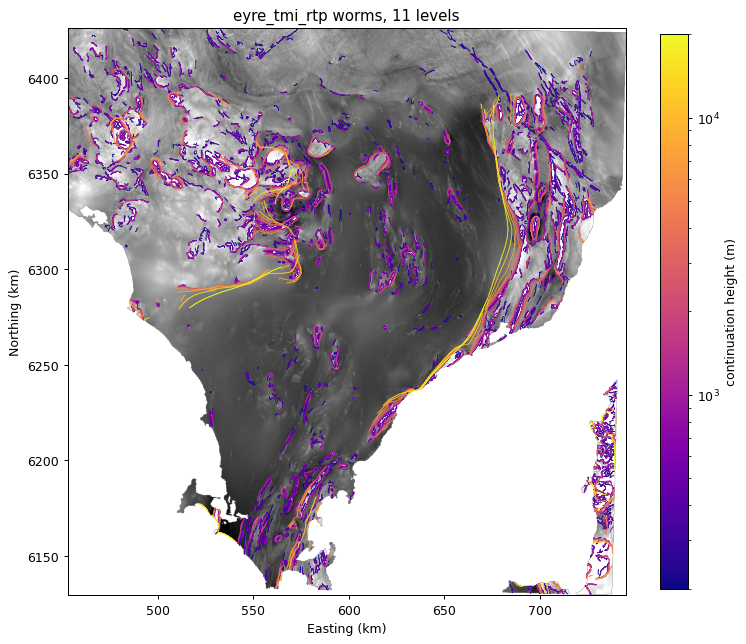

In [7]:
ax = worms.plot_map(wf, grid=rtp, s=0.4)
ax.figure.set_size_inches(10, 10)

At 200 to 500 m every lithological contact in the basement shows. By 2 to
5 km the domain fabric has collapsed to a few long strings, and what is
left at 12 to 20 km are the structures that reach through the crust: the
Kalinjala Shear Zone should be the most persistent north-south string on
the eastern side. The 3D view is plotted with height downward, the usual
display convention, so it reads like a depth section even though the
vertical axis is continuation height.

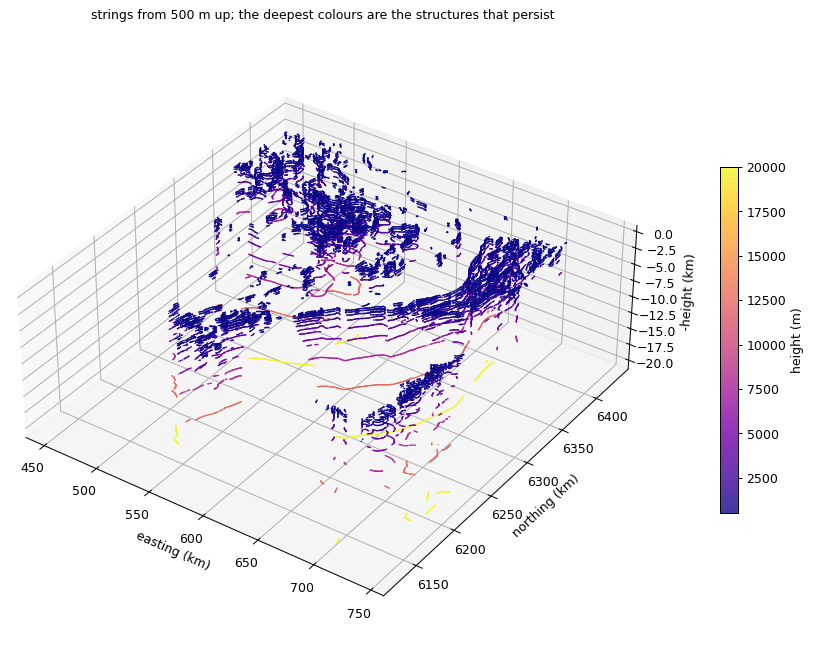

In [8]:
ax = worms.plot_3d(wf, vertical="down", exaggeration=6, s=1.2, stride=2, min_height=500, elev=35, azim=-55)
ax.set_title("strings from 500 m up; the deepest colours are the structures that persist", fontsize=10)
ax.figure.set_size_inches(12, 10)

The same view from the south-east, looking along the shear zone.

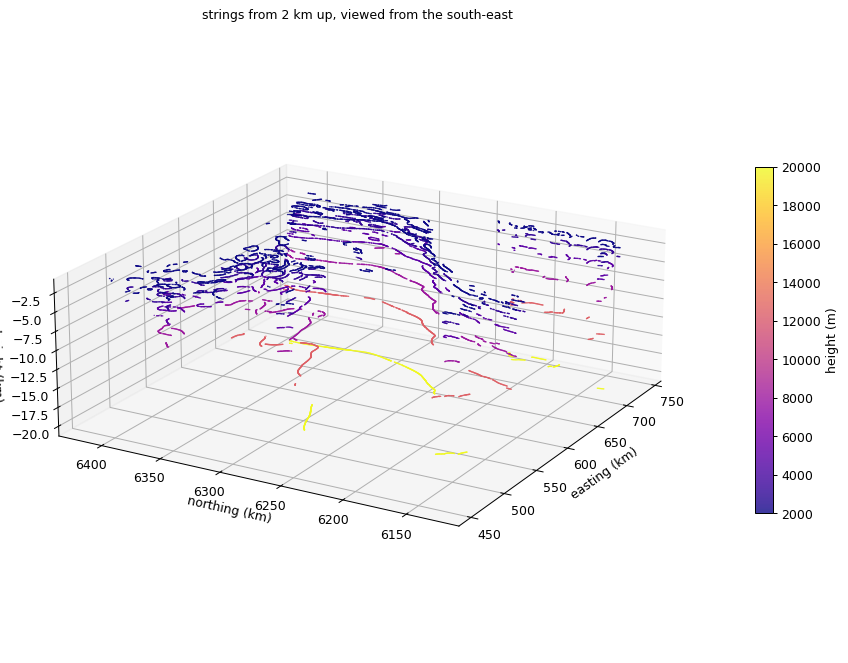

In [9]:
ax = worms.plot_3d(wf, vertical="down", exaggeration=6, s=1.2, stride=2, min_height=2000, elev=20, azim=-150)
ax.set_title("strings from 2 km up, viewed from the south-east", fontsize=10)
ax.figure.set_size_inches(12, 10)

## Chains, dips and depths

Link across heights and list the longest chains. `rate` is the horizontal
migration per metre of height. A contact migrates at most one metre per
metre (a horizontal contact); anything faster means the string is the
flank of a body whose width is comparable to the height, and the dip
column is left blank. Dips are only meaningful for single strings over
contacts, so treat the table as a screening list to check against the
map and the modelling, not as answers. The depths assume the contact
decay law.

In [10]:
worms.link_levels(wf)
chains_f = worms.chains(wf, min_levels=7)
print(len(chains_f), "chains through 7 or more heights\n")
rows = []
for c in chains_f:
    p = worms.chain_profile(wf, c)
    d = worms.contact_dip(wf, c)
    z = worms.depth_from_decay(p["height"], p["amplitude"], n=1.0)
    rows.append((len(c), p["x"][0] / 1e3, p["y"][0] / 1e3, p["height"][-1], d["rate"],
                 d["dip"] if d["rate"] <= 1.0 else np.nan, d["azimuth"], z["depth"], z["misfit"]))
rows.sort(key=lambda r: (-r[0], -r[3]))
print(f"{'levels':>6} {'E km':>7} {'N km':>8} {'top h m':>8} {'rate':>5} {'dip':>5} {'toward':>6} {'depth m':>8} {'misfit':>6}")
for r in rows[:15]:
    dip = f"{r[5]:5.0f}" if np.isfinite(r[5]) else "    -"
    print(f"{r[0]:6d} {r[1]:7.1f} {r[2]:8.1f} {r[3]:8.0f} {r[4]:5.2f} {dip} {r[6]:6.0f} {r[7]:8.0f} {r[8]:6.2f}")

321 chains through 7 or more heights



levels    E km     N km  top h m  rate   dip toward  depth m misfit
    11   679.4   6382.0    20000  4.17     -    188      652   0.28
    11   672.6   6371.5    20000  3.61     -    184       92   0.22
    11   674.2   6378.6    20000  3.97     -    184      100   0.26
    11   681.4   6342.1    20000  2.22     -    198       88   0.19
    11   579.1   6355.8    20000  0.85     9    229      331   0.06
    11   574.9   6353.8    20000  0.63    26    223      304   0.04
    11   577.0   6354.8    20000  0.74    17    226      309   0.04
    11   577.2   6348.6    20000  0.58    30    250       84   0.14
    11   574.1   6346.2    20000  0.40    47    258      194   0.30
    11   679.9   6344.7    20000  2.32     -    195       79   0.15
    11   562.2   6343.6    20000  0.22    65     75      570   0.15
    11   570.7   6343.7    20000  0.22    65    283      302   0.23
    11   577.1   6344.1    20000  0.54    33    273      -99   0.20
    11   555.0   6343.7    20000  0.58    30    

## Export

CSV loads into Geotools or QGIS as points with height and amplitude
attributes; the VTK file opens in ParaView for an interactive 3D view.

In [11]:
import os
os.makedirs(OUT, exist_ok=True)
print(wf.to_csv(f"{OUT}/eyre_worms.csv"))
print(wf.to_vtk(f"{OUT}/eyre_worms.vtk", vertical="down"))

..\outputs\eyre_worms.csv


..\outputs\eyre_worms.vtk
